<a href="https://colab.research.google.com/github/haseebkhanmhk10-crypto/DeveloperHub-Corporation-internship-Data-Analysis-/blob/main/Credit_Risk_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Task 2: Credit Risk Prediction**

## Import Libraries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as scn

## Load Data

In [ ]:
df_LPD = pd.read_csv('Loan Prediction Dataset (train).csv')
df_LPD

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


## Cleaning Data

In [ ]:
# To identify categorical and numerical columns with missing values
missing_categorical_cols = ['Gender', 'Dependents', 'Self_Employed', 'Credit_History']
missing_numerical_cols = ['LoanAmount', 'Loan_Amount_Term']

# To impute categorical columns with mode
for col in missing_categorical_cols:
    if col in df_LPD.columns:
        mode_val = df_LPD[col].mode()[0]
        df_LPD[col].fillna(mode_val, inplace=True)
        print(f"Filled missing values in '{col}' with mode: {mode_val}")

# To Impute numerical columns with median
for col in missing_numerical_cols:
    if col in df_LPD.columns:
        median_val = df_LPD[col].median()
        df_LPD[col].fillna(median_val, inplace=True)
        print(f"Filled missing values in '{col}' with median: {median_val}")

# To Verify that there are no more missing values
print("\nChecking for remaining missing values:")
display(df_LPD.isnull().sum())

Filled missing values in 'Gender' with mode: Male
Filled missing values in 'Dependents' with mode: 0
Filled missing values in 'Self_Employed' with mode: No
Filled missing values in 'Credit_History' with mode: 1.0
Filled missing values in 'LoanAmount' with median: 128.0
Filled missing values in 'Loan_Amount_Term' with median: 360.0

Checking for remaining missing values:


/tmp/ipykernel_32741/462802999.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_LPD[col].fillna(mode_val, inplace=True)
/tmp/ipykernel_32741/462802999.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using

,0
Loan_ID,0
Gender,0
Married,3
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


## Visualize Loan Amount, Education, and Income

Loan Amount Histogram

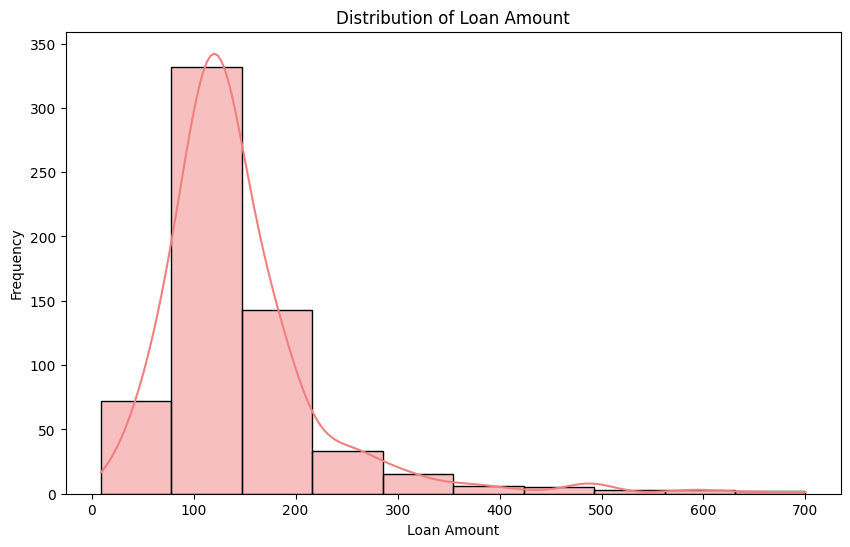

In [ ]:
plt.figure(figsize=(10, 6))
scn.histplot(df_LPD['LoanAmount'], bins=10, kde=True, color='lightcoral')
plt.title('Distribution of Loan Amount')
plt.xlabel('Loan Amount')
plt.ylabel('Frequency')
plt.show()

Education Level

/tmp/ipykernel_32741/1214825223.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  scn.countplot(x='Education', data=df_LPD, palette='viridis')


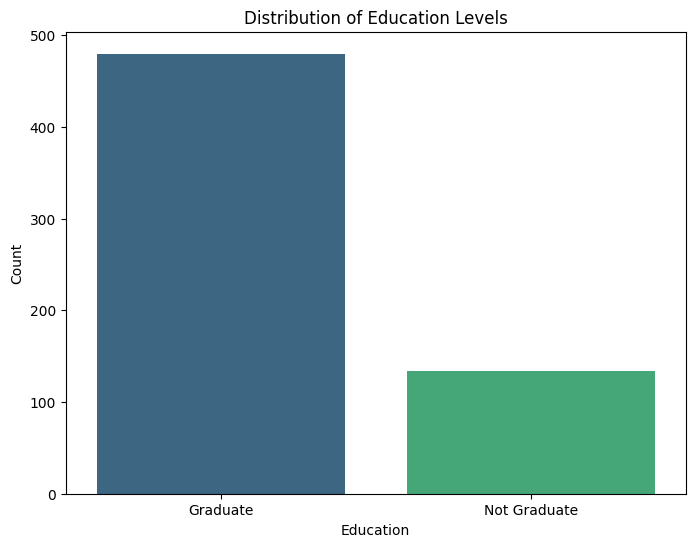

In [ ]:
plt.figure(figsize=(8, 6))
scn.countplot(x='Education', data=df_LPD, palette='viridis')
plt.title('Distribution of Education Levels')
plt.xlabel('Education')
plt.ylabel('Count')
plt.show()

Applicant Income

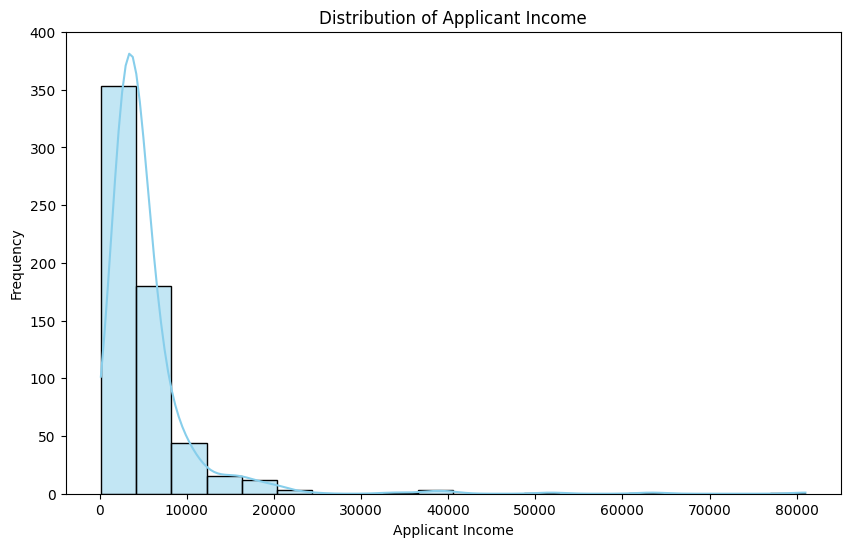

In [ ]:
plt.figure(figsize=(10, 6))
scn.histplot(df_LPD['ApplicantIncome'], bins=20, kde=True, color='skyblue')
plt.title('Distribution of Applicant Income')
plt.xlabel('Applicant Income')
plt.ylabel('Frequency')
plt.show()

## Classification Model
### Logistic Regression

Preparing Data

This involves:
1.  **Separating Features (X) and Target (y)**: The `Loan_Status` column will be the target variable.
2.  **Encoding Categorical Variables**: Converting categorical features into a numerical format that machine learning models can understand using one-hot encoding.
3.  **Splitting Data**: Dividing the dataset into training and testing sets to evaluate the model's performance on unseen data.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Separate features (X) and target (y)
X = df_LPD.drop('Loan_Status', axis=1)
y = df_LPD['Loan_Status']

# Encoding target variable 'Loan_Status' to numerical (Y->1, N->0)
le = LabelEncoder()
y = le.fit_transform(y)

print(f"Original target classes: {le.classes_}")
print(f"Encoded target mapping: {list(zip(le.classes_, [0, 1]))}")

# Identifying categorical and numerical features for preprocessing
categorical_features = X.select_dtypes(include=['object']).columns
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns

# Dropping 'Loan_ID' as it's an identifier and not a predictive feature
if 'Loan_ID' in categorical_features:
    categorical_features = categorical_features.drop('Loan_ID')
    X = X.drop('Loan_ID', axis=1)

# Creating a column transformer for one-hot encoding categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough'
)

# Apply preprocessing and split data
X_processed = preprocessor.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42, stratify=y)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Original target classes: ['N' 'Y']
Encoded target mapping: [('N', 0), ('Y', 1)]
Shape of X_train: (491, 21)
Shape of X_test: (123, 21)
Shape of y_train: (491,)
Shape of y_test: (123,)


### Training a Logistic Regression Model

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

log_reg_model = LogisticRegression(solver='liblinear', random_state=42)
log_reg_model.fit(X_train, y_train)

y_pred = log_reg_model.predict(X_test)

print("#### Logistic Regression Model Evaluation ####")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

#### Logistic Regression Model Evaluation ####
Accuracy: 0.8618

Classification Report:
              precision    recall  f1-score   support

           N       0.96      0.58      0.72        38
           Y       0.84      0.99      0.91        85

    accuracy                           0.86       123
   macro avg       0.90      0.78      0.81       123
weighted avg       0.88      0.86      0.85       123


Confusion Matrix:
[[22 16]
 [ 1 84]]


### Logestic Regression Model Evaluation
For the Logistic Regression model, we have the following evaluation:

Accuracy: 0.8618 (or 86.18%)

Confusion Matrix:

[[22 16]
 [ 1 84]]
Interpretation of the confusion matrix for the Logistic Regression model:

True Negatives (22): The model correctly predicted 22 instances where the loan was not approved (class 'N').

False Positives (16): The model incorrectly predicted 16 instances where the loan was approved (class 'Y'), but it was actually not approved.

False Negatives (1): The model incorrectly predicted 1 instance where the loan was not approved (class 'N'), but it was actually approved.

True Positives (84): The model correctly predicted 84 instances where the loan was approved (class 'Y').

### Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(max_depth=3, random_state=42)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)
print(f"Decision Tree Accuracy: {accuracy_score(y_test, dt_pred):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, dt_pred))

Decision Tree Accuracy: 0.8455

Confusion Matrix:
[[20 18]
 [ 1 84]]


### Decision Tree Evaluation
For Decision Tree we have the below evaluation

Confusion Matrix:

[[20 18]
 [ 1 84]]

True Negatives: The model correctly predicted 20 instances where the loan was not approved (class 'N').

False Positives: The model incorrectly predicted 18 instances where the loan was approved (class 'Y'), but it was actually not approved.

False Negatives: The model incorrectly predicted 1 instance where the loan was not approved (class 'N'), but it was actually approved.

True Positives: The model correctly predicted 84 instances where the loan was approved (class 'Y').

This indicates that the model is quite good at identifying approved loans (high True Positives) but has some difficulty with false positives, meaning it sometimes approves loans that should not have been. The single false negative is also a positive sign, as it means very few approved loans were missed by the model.